In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
base_url = "https://generativelanguage.googleapis.com/v1beta/openai/"

In [2]:
import json


def print_indented(obj):
    print(json.dumps(obj, indent=2))


def inspect(value, indent=0, prefix=""):
    space = "  " * indent

    if isinstance(value, dict):
        print(f"{space}{prefix}{{")
        for key, v in value.items():
            if isinstance(v, (dict, list)):
                inspect(v, indent + 1, prefix=f"{key!r}: ")
            else:
                print(f"{space}  {key!r}: {type(v).__name__}")
        print(f"{space}}}")

    elif isinstance(value, list):
        item = value[0] if value else None
        if isinstance(item, (dict, list)):
            # nested content -> expand over multiple lines
            print(f"{space}{prefix}[")
            inspect(item, indent + 1)
            print(f"{space}]")
        else:
            # simple type -> all on one line
            item_type = type(item).__name__ if value else ""
            print(f"{space}{prefix}[ {item_type} ]")


# Create an Embeddings Request


In [3]:
from openai import OpenAI
import openai

client = OpenAI(api_key=api_key, base_url=base_url)
try:
    response = client.embeddings.create(
        model="gemini-embedding-001",
        input="Embeddings are a numerical representation of text that can be used  to measure the relatedness between two pieces of text",
    )

    response_dict = response.to_dict()
    print('Total number of embeddings: ',len(response_dict["data"]))
    print(response_dict["data"][0]["embedding"])
except openai.RateLimitError as e:
    print_indented(e.response.json())
except openai.NotFoundError as e:
    print_indented(e.response.json())

Total number of embeddings:  1
[0.0018808372551575303, 0.015723930671811104, -0.012652418576180935, -0.059697411954402924, -0.01508838590234518, -0.008330103009939194, 0.007661198731511831, 0.013884393498301506, -0.014869806356728077, 0.0018660830100998282, 0.017045071348547935, -0.01535118743777275, -0.0036421390250325203, 0.02119215950369835, 0.11033257842063904, 0.025712518021464348, 0.00914156623184681, 0.008604897186160088, 0.005020247772336006, -0.007474351674318314, -0.0029165304731577635, 0.003458671737462282, -0.014050290919840336, -0.0074203903786838055, 0.00824675615876913, -0.0047412896528840065, 0.017389874905347824, 0.020655766129493713, 0.006510520353913307, 0.0207337848842144, 0.012506692670285702, 0.004433366935700178, 0.021552056074142456, 0.024966640397906303, 0.004920748993754387, 0.001981059554964304, 0.001846492406912148, -0.00296997232362628, 0.008353610523045063, 0.017617646604776382, -0.005912235006690025, -0.008784615434706211, -0.014815314672887325, 0.0094513

In [1]:
import json

with open("products.json", "r", encoding="utf-8") as f:
    products = json.load(f)

In [5]:
print('Total number of products:', len(products))
print_indented(products[0])

Total number of products: 19
{
  "title": "Smartphone X1",
  "short_description": "The latest flagship smartphone with AI-powered features and 5G connectivity.",
  "price": 799.99,
  "category": "Electronics",
  "features": [
    "6.5-inch AMOLED display",
    "Quad-camera system with 48MP main sensor",
    "Face recognition and fingerprint sensor",
    "Fast wireless charging"
  ]
}


# Embedding product descriptions


In [6]:
from openai import OpenAI
import openai

client = OpenAI(api_key=api_key, base_url=base_url)

product_descriptions = [product["short_description"] for product in products]

try:
    response = client.embeddings.create(
        model="gemini-embedding-001", input=product_descriptions
    )

    response_dict = response.to_dict()
    print('Total number of embeddings: ',len(response_dict["data"]))
    #print()
    for i, product in enumerate(products):
        product["embedding"] = response_dict["data"][i]["embedding"]
except openai.RateLimitError as e:
    print_indented(e.response.json())
except openai.NotFoundError as e:
    print_indented(e.response.json())
except TypeError as e: 
    print(e)
except AttributeError as e: 
    print(e)
    
inspect(products)

Total number of embeddings:  19
[
  {
    'title': str
    'short_description': str
    'price': float
    'category': str
    'features': [ str ]
    'embedding': [ float ]
  }
]


## Visualizing the embedded descriptions 

In [7]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Create reviews and embeddings lists using list comprehensions
categories = [product['category'] for product in products]
embeddings = [product['embedding'] for product in products]

# Reduce the number of embeddings dimensions to two using t-SNE
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

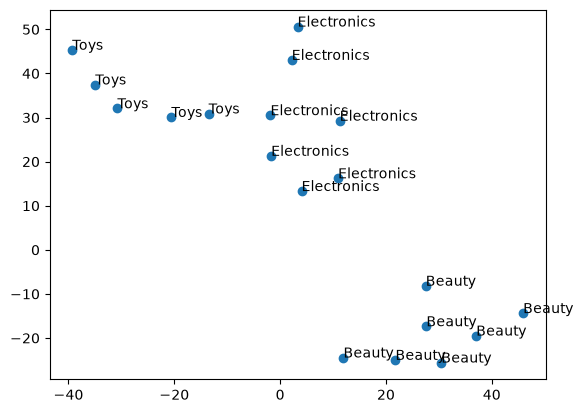

In [8]:
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
for i, category in enumerate(categories):
    plt.annotate(category, (embeddings_2d[i,0], embeddings_2d[i,1]))

plt.show()

In [9]:
print(np.array([[1, 2], [3, 4], [5, 6]]))
print(len(embeddings))
print(np.array(embeddings).shape)
print(embeddings_2d)

[[1 2]
 [3 4]
 [5 6]]
19
(19, 3072)
[[ 11.26369    29.274961 ]
 [ 45.93743   -14.356152 ]
 [-13.497966   30.910957 ]
 [ -1.6902268  21.31788  ]
 [ 27.532703   -8.157157 ]
 [-39.27719    45.359097 ]
 [  4.058556   13.32698  ]
 [ 21.804352  -24.964785 ]
 [ -1.8184024  30.526846 ]
 [ 11.981244  -24.43537  ]
 [-34.92502    37.488087 ]
 [ 10.955407   16.213207 ]
 [ 37.06502   -19.46013  ]
 [-30.737324   32.09369  ]
 [  3.3008945  50.627865 ]
 [ 30.468012  -25.576963 ]
 [-20.544737   30.125446 ]
 [  2.194924   43.076614 ]
 [ 27.649939  -17.342125 ]]
